In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

In [ ]:
def load_xy(path):
    df = pd.read_csv(path)
    y = df["class"].to_numpy().astype(int)
    X = df.drop(columns="class").to_numpy(dtype=float)
    return X, y


X_train, y_train = load_xy("data/RingSynTrain.csv")
X_test, y_test = load_xy("data/RingSynTest.csv")
print("train:", X_train.shape, " test:", X_test.shape)

train: (453, 2)  test: (300, 2)


In [45]:
mlp = MLPClassifier(
    hidden_layer_sizes=(8, ),   # one hidden layer, 8 neurons
    activation="relu",
    max_iter=2000,
    random_state=42,
)
mlp.fit(X_train, y_train)

train_acc = mlp.score(X_train, y_train)
test_acc  = mlp.score(X_test,  y_test)
majority  = np.bincount(y_test).max() / len(y_test)
print(f"MLP train accuracy:       {train_acc:.4f}")
print(f"MLP test accuracy:        {test_acc:.4f}")
print(f"Majority-class baseline:  {majority:.4f}")
print(f"Converged in {mlp.n_iter_} Epochs (final loss {mlp.loss_:.4f})")

MLP train accuracy:       0.9227
MLP test accuracy:        0.9233
Majority-class baseline:  0.6567
Converged in 1046 Epochs (final loss 0.2093)


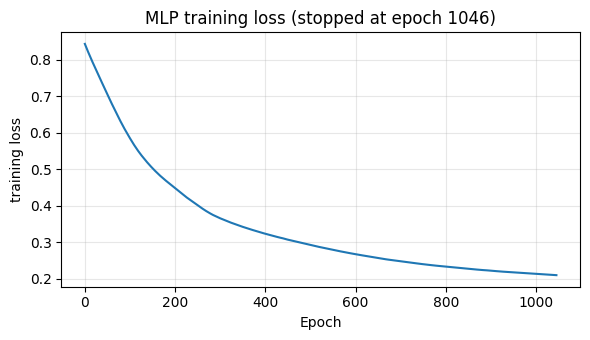

In [46]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(mlp.loss_curve_)
ax.set_xlabel("Epoch")
ax.set_ylabel("training loss")
ax.set_title(f"MLP training loss (stopped at epoch {mlp.n_iter_})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

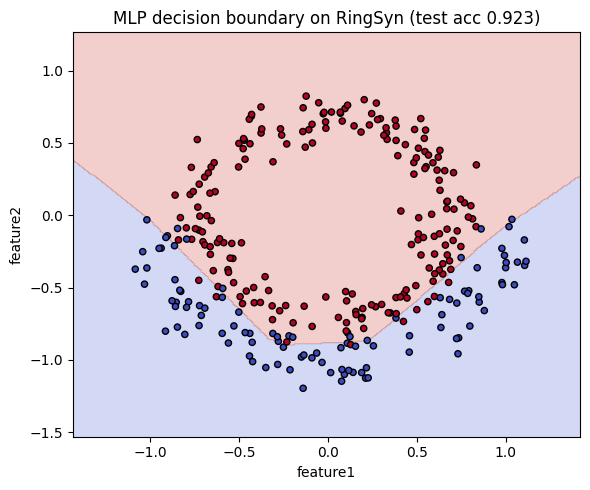

In [47]:
# Build a grid over the feature space and colour it by the MLP's prediction.
x_min, x_max = X_train[:, 0].min() - 0.3, X_train[:, 0].max() + 0.3
y_min, y_max = X_train[:, 1].min() - 0.3, X_train[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = mlp.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm",
           edgecolor="k", s=20)
ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_title(f"MLP decision boundary on RingSyn (test acc {test_acc:.3f})")
plt.tight_layout()
plt.show()